### 24RB1075 小嶋将太郎

### 演習1

In [94]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel


In [95]:
print("---1.グラフラプラシアンLと0固有値---")

#　隣接行列Wの作成
W = np.zeros((12, 12))

for i in range(6):
    for j in range(6):
        if i != j:
            W[i, j] = 1

for i in range(6, 12):
    for j in range(6, 12):
        if i != j:
            W[i, j] = 1

# グラフラプラシアン(L)
D = np.diag(np.sum(W, axis=1)) #各行の和を対角成分に持つ行列D
L = D - W

eigvals, eigvecs = np.linalg.eigh(L) #固有値分解
print(f'\nLの固有値 : {np.round(eigvals, 5)}')

zero_count = np.sum(np.round(eigvals, 5)==0) #0固有値の数をカウント
print(f'0固有値の数 : {zero_count}個')


---1.グラフラプラシアンLと0固有値---

Lの固有値 : [0. 0. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6.]
0固有値の数 : 2個


In [96]:

print("---2.ノイズを加えた際のWの固有値---")
W_noise = W.copy()

for i in range(12):
    for j in range(12):
        if i != j and W_noise[i, j] == 0:
            noise = np.random.random() * 0.1 #各場所で異なる小さな正のノイズを加える
            W_noise[i, j] = noise

# 非対象な行列の固有値計算
eigvals_W, eigvecs_W = np.linalg.eig(W_noise)

print("\nWの固有値:")
for i , val in enumerate(eigvals_W):
    print(f"λ{i+1} = {val.real:.2f} + {val.imag:.2f}j")

---2.ノイズを加えた際のWの固有値---

Wの固有値:
λ1 = 5.31 + 0.00j
λ2 = 4.69 + 0.00j
λ3 = -1.06 + 0.00j
λ4 = -0.94 + 0.00j
λ5 = -1.02 + 0.03j
λ6 = -1.02 + -0.03j
λ7 = -0.98 + 0.03j
λ8 = -0.98 + -0.03j
λ9 = -1.01 + 0.02j
λ10 = -1.01 + -0.02j
λ11 = -0.99 + 0.02j
λ12 = -0.99 + -0.02j


---3.対称性を保った隣接行列の再定義とプロット---

ラプラシアンの固有値:
λ1 = -0.00
λ2 = 0.61
λ3 = 6.20
λ4 = 6.26
λ5 = 6.27
λ6 = 6.29
λ7 = 6.29
λ8 = 6.32
λ9 = 6.33
λ10 = 6.34
λ11 = 6.37
λ12 = 6.40


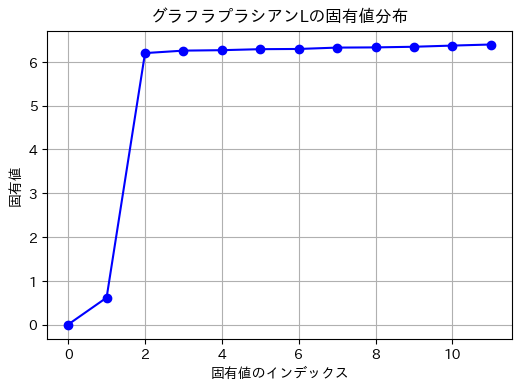

In [97]:
print("---3.対称性を保った隣接行列の再定義とプロット---")
W_sym = (W_noise + W_noise.T) / 2

# 新しいグラフラプラシアンの計算
D_sym = np.diag(np.sum(W_sym, axis = 1))
L_sym = D_sym - W_sym

# 固有値分解
eigvals, eigvecs = np.linalg.eigh(L_sym)

print("\nラプラシアンの固有値:")
for i, val in enumerate(eigvals):
    print(f"λ{i+1} = {val:.2f}")

plt.figure(figsize=(6, 4))
plt.plot(range(12), eigvals, marker='o', linestyle='-', color='b')
plt.xlabel("固有値のインデックス")
plt.ylabel("固有値")
plt.title("グラフラプラシアンLの固有値分布")
plt.grid(True)
plt.show()

### 演習２

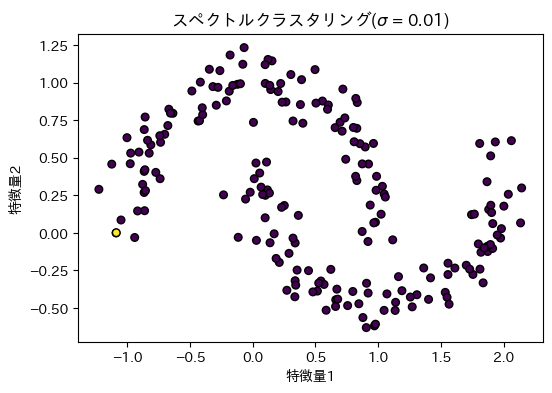

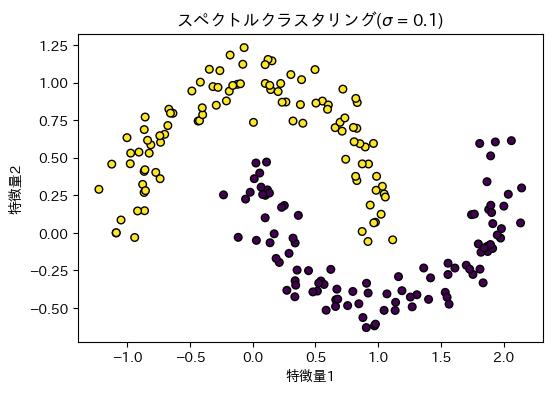

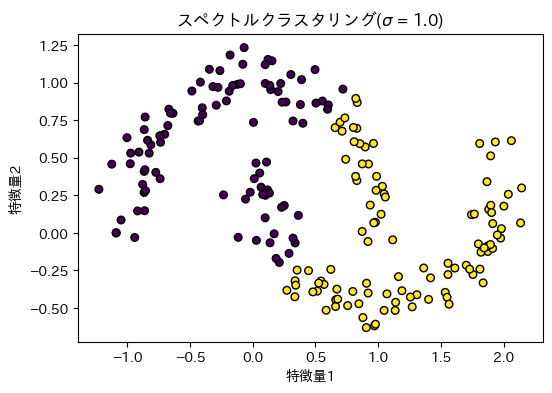

In [98]:
# 1.データの生成
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)

sigmas = [0.01, 0.1, 1.0]

for i, sigma in enumerate(sigmas):
    plt.figure(figsize=(6, 4))
    # RBFカーネルの計算
    gamma = 1 / (2 * sigma**2)
    W = rbf_kernel(X, gamma=gamma)
    np.fill_diagonal(W, 0)

    D = np.diag(np.sum(W, axis = 1))
    L = D - W

    eigvals, eigvecs = np.linalg.eigh(L)
    U = eigvecs[:, :2]

    kmeans = KMeans(n_clusters=2, random_state=42, n_init="auto") 
    labels= kmeans.fit_predict(U)
    
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30, edgecolors='k')
    plt.title(f"スペクトルクラスタリング($\sigma$ = {sigma})")
    plt.xlabel("特徴量1")
    plt.ylabel("特徴量2")
    plt.show()

### 考察
課題1より、グラフが2グループに分離されているとき、0固有値がちょうど2個出ることを確認できた。ノイズによって非対称行列となると固有値に複素数が現れるため、対称性を保つことが重要だと考えられた。また、課題2では、σの値によって結果に違いがみられた。σが小さすぎると、点同士がつながらず、1点だけが孤立した分類となり、また大きすぎると三日月の形を無視した直線的な分類になってしまった。データの形に合わせてσを適切に調節する必要があった。

### AIの使用
プログラムの複雑な部分はAIから雛形を提示してもらいヒントを得た。ヒントから、実際に今回使用した関数や変数に当てはめてプログラムを実装した。また、RBFカーネルにおけるσとγの関係性などの理解度を深めるために活用した。